CHARGEMENT DES DONNEES

In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("dataset_enrichi_final.csv")
df.head()

,ID_Patient,Age,Sexe,Zone,Saison,Duree_Fievre_Jours,Temperature,Frissons,Maux_de_tete,Vomissements,...,Sudation,Douleurs_articulaires,Eruption_cutanee,Ictere,Douleurs_abdominales,Confusion,Photophobie,Mal_de_gorge,Ecoulement_nasal,Maladie
0,PAT_00001,38,F,Rural,Seche,4,38.20,1,1,1,...,0,1,0,1,0,1,0,1,0,Fievre_jaune
1,PAT_00002,10,F,Rural,Seche,3,38.88,0,0,0,...,1,0,0,0,0,1,0,1,0,Infection_respiratoire
2,PAT_00003,29,M,Rural,Seche,6,38.40,1,1,1,...,1,1,0,0,0,1,0,0,0,Typhoide
3,PAT_00004,22,F,Rural,Pluies,1,39.89,0,0,0,...,0,0,0,0,1,0,0,0,0,Diarrhee
4,PAT_00005,14,M,Rural,Pluies,1,39.17,1,1,1,...,1,0,0,0,1,1,0,0,0,Paludisme


### EXPLORATION DES DONNEES

In [3]:
import matplotlib.pyplot as plt

#### I)Le nombre de cas par maladie

In [4]:
#le nombre de cas par maladie
nombre_de_cas = df["Maladie"].value_counts()
print(nombre_de_cas)

Maladie
Paludisme                 1800
Typhoide                  1400
Meningite                 1300
Infection_respiratoire    1200
Dengue                    1200
Fievre_jaune              1100
Diarrhee                  1100
Sain                      1000
Name: count, dtype: int64


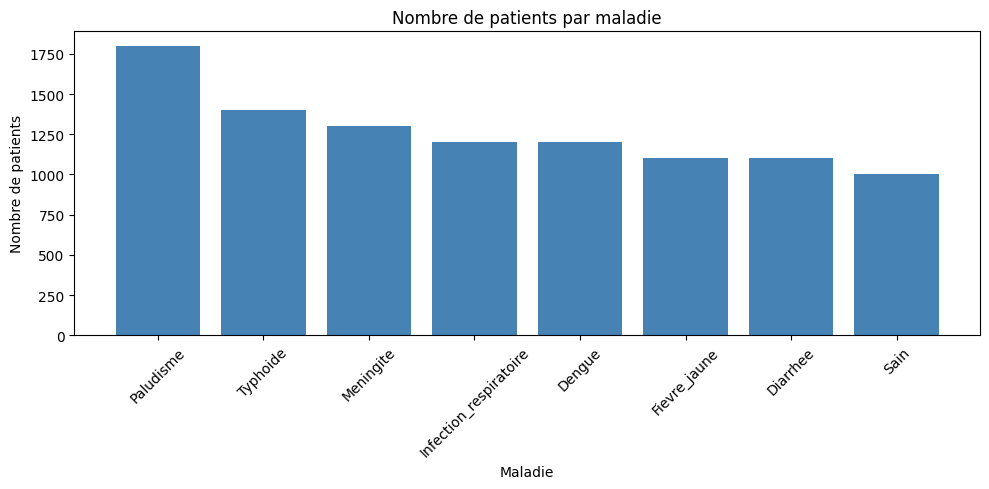

In [5]:
plt.figure(figsize=(10,5))
plt.bar(
    nombre_de_cas.index,
    nombre_de_cas.values,
    color = "steelblue"
)
plt.title("Nombre de patients par maladie")
plt.xlabel("Maladie")
plt.ylabel("Nombre de patients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### II)la temperature varie-t-elle selon la maladie ?

C:\Users\bobma\AppData\Local\Temp\ipykernel_17852\900860250.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groupes, labels = noms_des_maladies)


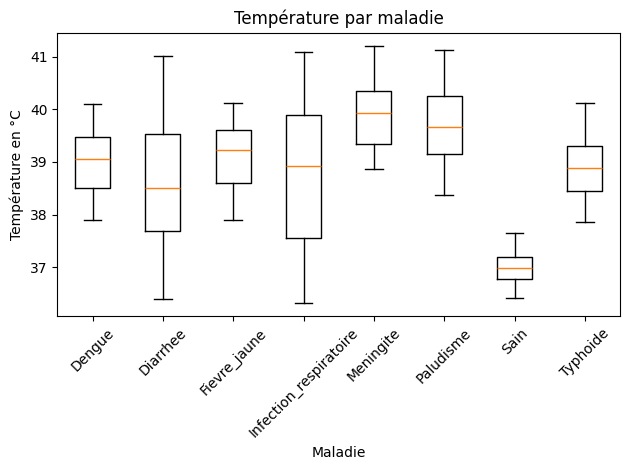

In [6]:
#les noms de maladies
noms_des_maladies = []
#on récupère les températures
groupes = []
for nom, groupe in df.groupby("Maladie"):
    noms_des_maladies.append(nom)
    groupes.append(groupe["Temperature"].values)

#visualisation
plt.boxplot(groupes, labels = noms_des_maladies)
plt.title("Température par maladie")
plt.xlabel("Maladie")
plt.ylabel("Température en °C")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()


#### III)le heatmap des symptomes

Symptomes trouvés: ['Frissons', 'Maux_de_tete', 'Vomissements', 'Fatigue', 'Douleurs_musculaires', 'Toux', 'Symptome_diarrhee', 'Raideur_cou', 'Sudation', 'Douleurs_articulaires', 'Eruption_cutanee', 'Ictere', 'Douleurs_abdominales', 'Confusion', 'Photophobie', 'Mal_de_gorge', 'Ecoulement_nasal']
                          Frissons  Maux_de_tete  Vomissements     Fatigue  \
Maladie                                                                      
Dengue                   45.750000     46.583333     55.916667  100.000000   
Diarrhee                 56.454545     53.454545     45.181818   45.000000   
Fievre_jaune             52.727273     46.818182    100.000000  100.000000   
Infection_respiratoire   53.750000     54.416667     46.416667  100.000000   
Meningite                40.384615    100.000000     45.384615   45.538462   
Paludisme               100.000000    100.000000     47.111111  100.000000   
Sain                      0.000000      0.000000      0.000000    0.000000   


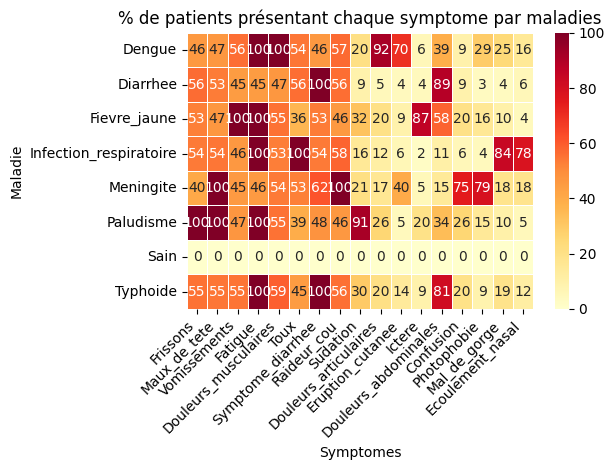

In [10]:
import seaborn as sns
colonnes_a_exclure = ["ID_Patient","Age","Sexe","Zone",
                      "Saison","Duree_Fievre_Jours",
                      "Temperature","Maladie"]
symptomes = [col for col in df.columns 
             if col not in colonnes_a_exclure]
print("Symptomes trouvés:", symptomes)
heatmap_donnees = df.groupby("Maladie")[symptomes].mean()*100
print(heatmap_donnees)
plt.Figure(figsize=(16,6))
sns.heatmap(
    heatmap_donnees,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5
)
plt.title("% de patients présentant chaque symptome par maladies")
plt.xlabel("Symptomes")
plt.ylabel("Maladie")
plt.xticks(rotation = 45,ha = "right")
plt.tight_layout()
plt.show()

#### IV) le paludisme est-il plus présent pendant la saison des pluies ?

Saison                  Pluies  Seche
Maladie                              
Dengue                     885    315
Diarrhee                   564    536
Fievre_jaune               854    246
Infection_respiratoire     339    861
Meningite                  651    649
Paludisme                 1396    404
Sain                       489    511
Typhoide                   710    690


<Figure size 1200x600 with 0 Axes>

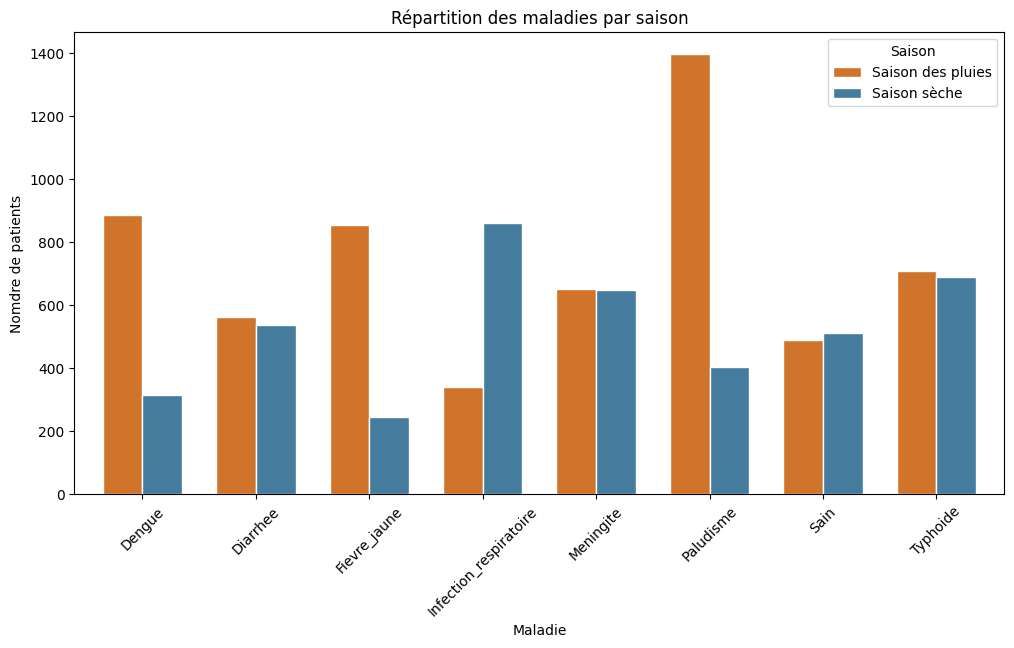

In [13]:
tableau = pd.crosstab(df["Maladie"],df["Saison"])
print(tableau)

plt.figure(figsize= (12,6))
tableau.plot(
    kind = "bar",
    figsize=(12,6),
    color=["#CF742A", '#457B9D'],
    width= 0.7,
    edgecolor= "white"
    
)
plt.title("Répartition des maladies par saison")
plt.xlabel("Maladie")
plt.ylabel("Nomdre de patients")
plt.xticks(rotation = 45,)
plt.legend(title="Saison", labels=["Saison des pluies","Saison sèche"])
#plt.tight_layout()
plt.show()

#### V)quelles tranches d'ages sont les plus touchés

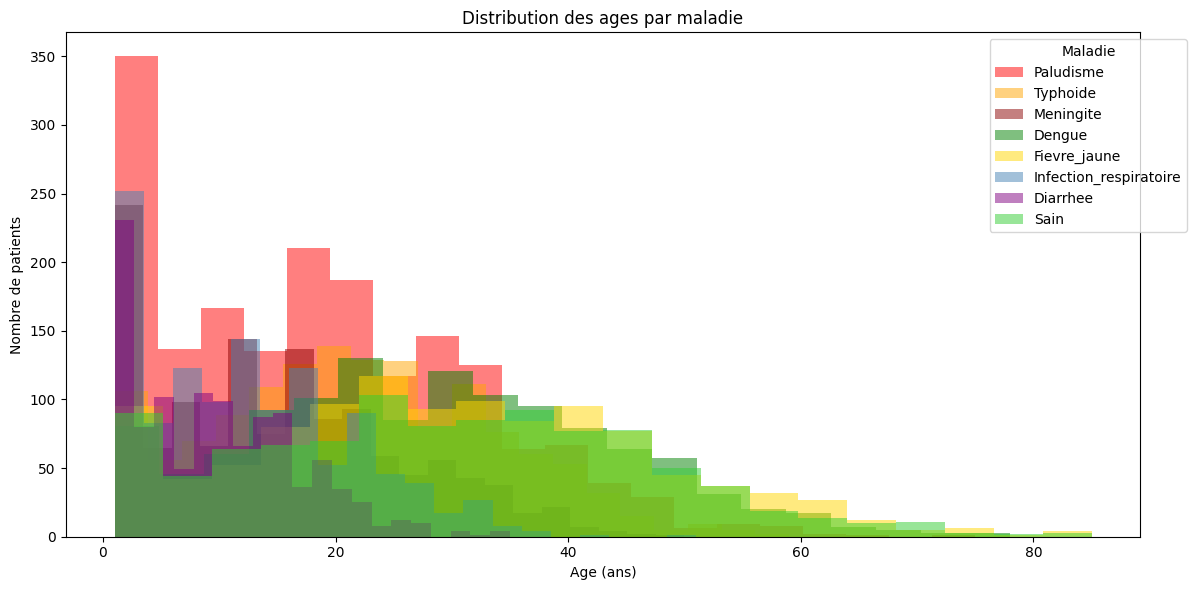

In [17]:
couleurs = {
    "Paludisme":              "red",
    "Typhoide":               "orange",
    "Meningite":              "darkred",
    "Dengue":                 "green",
    "Fievre_jaune":           "gold",
    "Infection_respiratoire": "steelblue",
    "Diarrhee":               "purple",
    "Sain":                   "limegreen",
}
plt.figure(figsize=(12,6))
for maladie, couleur in couleurs.items():
    ages = df[df["Maladie"]== maladie]["Age"]
    plt.hist(
        ages,
        bins=20,
        alpha=0.5,
        label=maladie,
        color=couleur
    )
plt.title("Distribution des ages par maladie")
plt.xlabel("Age (ans)")
plt.ylabel("Nombre de patients")
plt.legend(title="Maladie",bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()
